# Perturbation LOO Evaluation

Evaluates the perturbation model on a held-out cell type in the CRC region.
For each cell type we compute the top-100 pseudobulk logFC genes (CRC vs REF),
perturb REF cells' spatial context accordingly, and measure how well the
predicted expression shift matches the real CRC expression.

In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

import sys
sys.path.append('src')

import numpy as np
import pandas as pd
import scanpy as sc
import decoupler as dc
import matplotlib.pyplot as plt
import scvi

from cellina import CellinaModel, make_neighbor_perturbation
from src.cellina._spatial_utils import spatial_neighbors, compute_spatial_features

from perturb_utils import load_crc_slide, split_indices, compute_cf_logfc, load_crc_slide

plt.rcParams['figure.dpi'] = 75
scvi.settings.seed = 0

/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/data/ddimitrov/software/miniforge3/envs/cellina/l

In [2]:
# ── Config ──────────────────────────────────────────────────────────────────
slide_id         = 232
labels_key       = 'coarse_type'
domains_key      = 'typ'
holdout_celltype = 'T_cell'
top_n_perturb    = 50   # genes used to perturb spatial context
top_n            = 100   # genes used to evaluate metrics
min_cells        = 50    # minimum cells per domain per cell type to evaluate
batch_size       = 512
base_path        = 'results/perturb_loo'
save_path        = f'{base_path}/trained/crc_{slide_id}_{holdout_celltype}'
library_size     = 1e4

## 1. Data Loading

In [3]:
adata = load_crc_slide(slide_id, labels_key=labels_key, domains_key=domains_key)
print(adata)

AnnData object with n_obs × n_vars = 111989 × 3000
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68_CK8_18', 'Max.CD68_CK8_18', 'Mean.CD298_B2M', 'Max.CD298_B2M', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'cell_id', 'Dash', 'ISH.concentration', 'Panel', 'Run_Tissue_name', 'Run_name', 'assay_type', 'dualfiles', 'tissue', 'version', 'slide_ID', 'CenterX_global_px', 'CenterY_global_px', 'cell_ID', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprobes_quantile_0.99', 'nCount_negprobes', 'nFeature_negprobes', 'median_falsecode', 'falsecode_quantile_0.75', 'falsecode_quantile_0.8', 'falsecode_quantile

## 2. Holdout Split

Mark `holdout_celltype` cells in CRC regions as test (holdout). These cells are used
**only for evaluation** — their ground-truth CRC expression is the target we compare against.

In [4]:
train_idx, val_idx, test_idx = split_indices(
    adata, holdout_celltype=holdout_celltype,
    labels_key=labels_key, domains_key=domains_key,
)

print(f"train: {len(train_idx):,}  val: {len(val_idx):,}  test (holdout): {len(test_idx):,}")
print(f"Holdout cells: {adata.obs['is_holdout'].sum()} {holdout_celltype} in CRC region")

train: 98,277  val: 10,919  test (holdout): 2,793
Holdout cells: 2793 T_cell in CRC region


## 3. Spatial Graph & Features

In [ ]:
spatial_neighbors(adata, bandwidth=100 / 0.12028, max_neighbours=None, standardize=False)
compute_spatial_features(adata)

In [25]:
adata.obsm['spatial'][:,0].min(), adata.obsm['spatial'][:,0].max()

(71913, 110095)

In [26]:
adata.obsm['spatial'][:,1].min(), adata.obsm['spatial'][:,1].max()

(63106, 109862)

## 4. Model Training

In [6]:
CellinaModel.setup_anndata(
    adata,
    batch_key=None,
    labels_key=labels_key,
    domains_key=domains_key,
    layer='counts',
    spatial_obsm_key='spatial_x',
)

model = CellinaModel(
    adata,
    n_latent=20,
    classifier_lambda=1,
    discriminator_lambda=1,
    n_layers=3,
    condition_on_intrinsic=False,
)

INFO     Generating sequential column names                                                                        
INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


In [7]:
model.train(
    max_epochs=30,
    check_val_every_n_epoch=1,
    early_stopping=True,
    early_stopping_patience=5,
    early_stopping_monitor='vae_loss_validation',
    train_size=0.9,
    validation_size=0.1,
    plan_kwargs={
        'lr': 0.001,
        'weight_decay': 0.0001,
        'normalize_losses': True,
    },
    datasplitter_kwargs={"external_indexing": [train_idx, val_idx, test_idx]},
    enable_checkpointing=True,
    batch_size=batch_size,
    devices=[0],
)

INFO: GPU available: True (cuda), used: True
2026-03-24 17:26:36 | [INFO] GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
2026-03-24 17:26:36 | [INFO] TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
2026-03-24 17:26:36 | [INFO] HPU available: False, using: 0 HPUs
INFO: You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
2026-03-24 17:26:36 | [INFO] You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.o

/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Training:   0%|          | 0/30 [00:00<?, ?it/s]

Monitored metric vae_loss_validation did not improve in the last 5 records. Best score: 461.712. Signaling Trainer to stop.


In [8]:
model.save(save_path, overwrite=True)

## 5. Pseudobulk logFC per Cell Type (CRC vs REF)

In [9]:
pdata = dc.pp.pseudobulk(
    adata=adata,
    sample_col=domains_key,
    groups_col=labels_key,
    mode='sum',
    layer='counts',
)
sc.pp.normalize_total(pdata, target_sum=1e4)
sc.pp.log1p(pdata)

ref_label = f'{slide_id}_REF'
crc_label = f'{slide_id}_CRC'

cell_types = [
    ct for ct in pdata.obs[labels_key].unique()
    if ((pdata.obs[domains_key] == ref_label) & (pdata.obs[labels_key] == ct)).any()
    and ((pdata.obs[domains_key] == crc_label) & (pdata.obs[labels_key] == ct)).any()
]

domain_logfc_df = pd.concat(
    [
        pd.Series(
            (
                pdata[(pdata.obs[domains_key] == crc_label) & (pdata.obs[labels_key] == ct)].X
                - pdata[(pdata.obs[domains_key] == ref_label) & (pdata.obs[labels_key] == ct)].X
            ).flatten(),
            index=pdata.var_names,
            name=ct,
        )
        for ct in cell_types
    ],
    axis=1,
).T

print(f"logFC matrix: {domain_logfc_df.shape}  (cell types × genes)")
domain_logfc_df.head()

logFC matrix: (7, 3000)  (cell types × genes)


,DES,SLC22A16,RNF186,TAFA3,GCSAM,RAB44,AWAT1,RTTN,MYO1F,PWWP2B,...,GPX8,ARMCX1,FBN2,ACYP2,RIPPLY1,PLAC8L1,LRCH2,ARHGAP6,DBNL,HAT1
Endothelial,-0.247933,0.030929,-0.132753,-0.074783,-0.336980,0.048579,-0.461400,-0.011090,-0.055737,-0.088087,...,-0.010124,-0.149009,-0.213081,-0.157315,-0.259867,-0.253751,-0.299324,-0.023891,-0.175992,0.199938
Epithelial,-0.033994,-0.457857,-0.222040,0.018591,-0.131009,-0.419756,-0.084441,-0.517717,-0.130881,-0.705174,...,-0.213566,-0.182887,-0.234025,-0.014209,-0.206537,-0.192728,-0.137533,0.023384,0.049195,0.113313
Fibroblast,-0.503774,-0.087190,-0.289097,-0.326220,-0.323539,-0.313739,-0.305978,-0.175104,-0.117715,-0.534841,...,-0.130831,-0.159516,-0.331626,-0.100066,-0.315532,-0.285171,-0.039989,-0.307851,-0.059330,-0.268954
Myeloid,-0.047840,-0.171747,-0.458499,0.336375,-0.701313,0.147773,0.168002,-0.076923,0.206223,-0.123577,...,-0.063122,-0.017510,-0.267740,0.063837,-0.058507,-0.525925,-0.069793,-0.284780,0.084352,0.174245
Plasma_cell,0.254469,0.104107,0.070434,0.043531,0.104575,0.145362,-0.042265,0.020217,0.298476,0.122146,...,0.090745,0.064771,0.177262,0.171509,0.001160,0.166247,0.101457,0.013942,-0.025968,0.145912


## 6. Perturbation: Top-100 Genes per Cell Type

In [10]:
logfc_series_dict = {}
for ct in domain_logfc_df.index:
    s = domain_logfc_df.loc[ct]
    top_genes = s.abs().nlargest(top_n_perturb).index.tolist()
    logfc_series_dict[ct] = s[top_genes]

make_neighbor_perturbation(
    adata,
    perturbations=logfc_series_dict,
    groupby=labels_key,
    obsm_key_out='spatial_x_cf',
    base=np.e,
)

## 7. Expression Retrieval & Metrics

In [11]:
rows = []
logfcs = {}

for ct in sorted(cell_types):
    ref_mask = (adata.obs[labels_key] == ct) & (adata.obs[domains_key] == ref_label)
    crc_mask = (adata.obs[labels_key] == ct) & (adata.obs[domains_key] == crc_label)

    # For the holdout cell type, evaluate only on holdout cells
    if ct == holdout_celltype:
        crc_mask = crc_mask & adata.obs['is_holdout']

    ref_idx = np.where(ref_mask.values)[0]
    crc_idx = np.where(crc_mask.values)[0]

    if len(ref_idx) < min_cells or len(crc_idx) < min_cells:
        print(f"  skip {ct}: ref={len(ref_idx)}, crc={len(crc_idx)}")
        continue

    print(f"  {ct}: ref={len(ref_idx)}, crc={len(crc_idx)}")

    # ref_expr  = model.get_normalized_expression(indices=ref_idx, batch_size=batch_size, library_size=library_size)
    ref_expr = sc.pp.normalize_total(adata[ref_idx], target_sum=library_size, inplace=False)['X']
    ref_expr = ref_expr.toarray() if hasattr(adata[ref_idx].X, 'toarray') else ref_expr
    pert_expr = model.get_perturbed_expression(adata=adata, indices=ref_idx, spatial_obsm_key='spatial_x_cf', batch_size=batch_size, library_size=library_size)
    cf_expr   = model.get_normalized_expression(indices=crc_idx, batch_size=batch_size, library_size=library_size)

    stats = compute_cf_logfc(
        ref_expr, pert_expr, cf_expr,
        top_n=top_n,
        gene_names=adata.var_names.tolist(),
    )

    rows.append(dict(
        cell_type=ct,
        holdout=(ct == holdout_celltype),
        n_ref=len(ref_idx),
        n_crc=len(crc_idx),
        pearson_r=stats['pearson_r'],
        spearman_r=stats['spearman_r'],
        precision=stats['precision'],
        mixing_index=stats['mixing_index'],
    ))
    logfcs[ct] = stats

summary_df = pd.DataFrame(rows).sort_values('pearson_r', ascending=False).reset_index(drop=True)
summary_df

  Endothelial: ref=1772, crc=4994


/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:207: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


  Epithelial: ref=12646, crc=37319


/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:207: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


  Fibroblast: ref=2881, crc=20695


...

  Smooth_muscle: ref=1528, crc=4157


/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:207: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


  T_cell: ref=1484, crc=2793


/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:207: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


,cell_type,holdout,n_ref,n_crc,pearson_r,spearman_r,precision,mixing_index
0,Smooth_muscle,False,1528,4157,0.995988,0.965125,0.87,0.854277
1,Endothelial,False,1772,4994,0.929553,0.779418,0.61,0.620582
2,Fibroblast,False,2881,20695,0.905096,0.851905,0.36,0.480117
3,Epithelial,False,12646,37319,0.902299,0.814101,0.44,0.566101
4,Myeloid,False,1033,5035,0.897908,0.674887,0.50,0.885624
5,Plasma_cell,False,8387,7265,0.821585,0.166121,0.59,0.885847
6,T_cell,True,1484,2793,0.697944,0.535242,0.34,0.808365


## 8. Visualization: logFC Scatter Plots

In [12]:
assert adata.obs.loc[adata.obs.index[model.test_indices_], labels_key].unique() == [holdout_celltype]

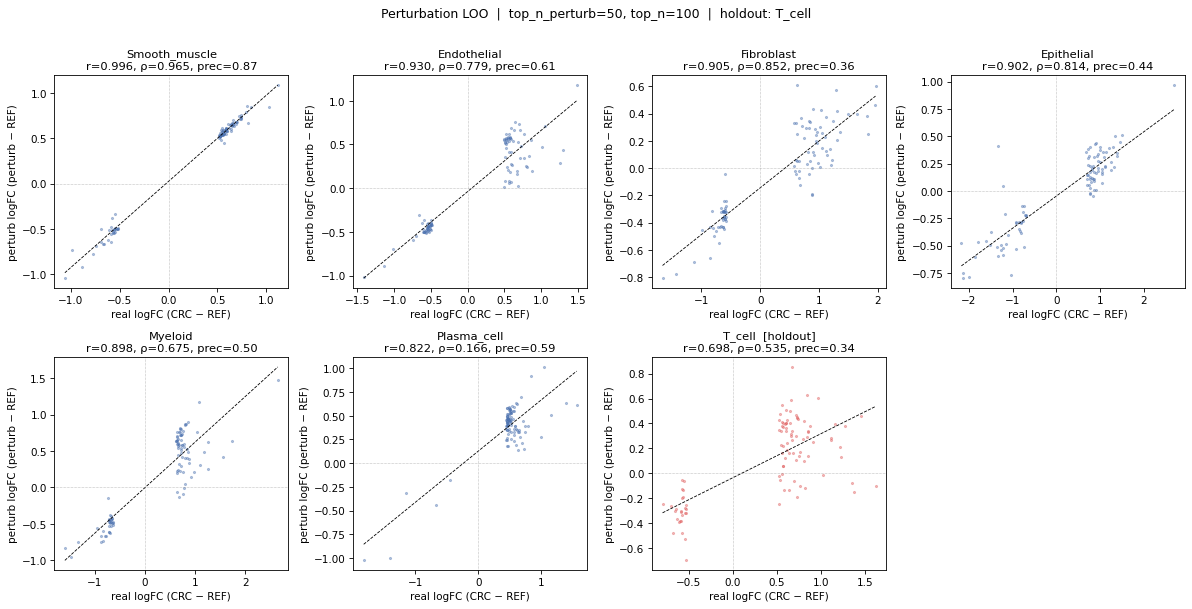

In [13]:
ncols = 4
nrows = (len(summary_df) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
axes = axes.flatten()

for i, row in summary_df.iterrows():
    ct  = row['cell_type']
    ax  = axes[i]
    real = logfcs[ct]['real_logfc']
    pred = logfcs[ct]['pred_logfc']
    mask = logfcs[ct]['top_n_mask']
    if mask is not None:
        real, pred = real[mask], pred[mask]

    color = '#e05c5c' if row['holdout'] else '#4C72B0'
    ax.scatter(real, pred, s=4, alpha=0.4, color=color)

    m, b = np.polyfit(real, pred, 1)
    x_lo, x_hi = real.min(), real.max()
    ax.plot([x_lo, x_hi], [m * x_lo + b, m * x_hi + b], color='k', lw=0.8, ls='--')
    ax.axhline(0, color='grey', lw=0.5, ls=':')
    ax.axvline(0, color='grey', lw=0.5, ls=':')

    title = f"{ct}{'  [holdout]' if row['holdout'] else ''}"
    ax.set_title(
        f"{title}\nr={row['pearson_r']:.3f}, ρ={row['spearman_r']:.3f}, prec={row['precision']:.2f}",
        fontsize=11,
    )
    ax.set_xlabel('real logFC (CRC − REF)', fontsize=10)
    ax.set_ylabel('perturb logFC (perturb − REF)', fontsize=10)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f"Perturbation LOO  |  top_n_perturb={top_n_perturb}, top_n={top_n}  |  holdout: {holdout_celltype}", y=1.01)
plt.tight_layout()
plt.show()